# 03b. Tabular Models — Regression, Classification, Clustering, Anomaly, SHAP

**Authors:** Fajar Laksono
**Methodology:** CRISP-ML(Q) + CAMS DevOps
**Last Updated:** 2026-05-12

This notebook loads pre-computed features from `03a_feature_engineering.ipynb` and trains all tabular models.

---

In [1]:
import os, sys, warnings, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
warnings.filterwarnings('ignore')

# Thin imports from app.src modules
from app.src.features import get_feature_target_columns
from app.src.models import (XGBoostModel, RandomForestModel, RidgeModel,
                            ClusterModel, AnomalyModel, load_model)
from app.src.visualize import residual_plot, feature_importance_plot, cluster_scatter, comparison_table

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# Gradient boosting
import xgboost as xgb

# Model persistence
import joblib

# Explainability
import shap

# Statistical
from scipy import stats

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries imported successfully.')


All libraries imported successfully.


In [2]:
DATA_DIR = pathlib.Path('data/transformed/parquet')
features_df = pd.read_parquet(DATA_DIR / 'features_df.parquet')
print(f'\u2713 features_df loaded: {len(features_df):,} rows, {len(features_df.columns)} columns')


✓ features_df loaded: 2,695,548 rows, 47 columns


## 0. Table of Contents

4. [Regression — Cost & Utilization Prediction](#4-regression--cost--utilization-prediction)
5. [Classification — Waste Detection](#5-classification--waste-detection)
6. [Clustering — Workload Segmentation](#6-clustering--workload-segmentation)
7. [Anomaly Detection for Cost Spikes](#7-anomaly-detection-for-cost-spikes)
9. [Explainability with SHAP](#9-explainability-with-shap)
10. [Model Comparison & Selection](#10-model-comparison--selection)
11. [Conclusions and Recommendations](#11-conclusions-and-recommendations)


## 1. Summary

**CRISP-ML(Q) Phase:** Business Understanding

### Business Question
How can we accurately predict cloud resource utilization, detect wasted resources, forecast costs, and segment workloads to enable data-driven FinOps decisions?

### Dataset
- **Source:** Azure Public Dataset V2 (2019 VM traces)
- **Size:** ~2.7 million VM records
- **Time range:** 30-day trace
- **Tables:** `vmtable`, `subscriptions`, `deployments`, `azure_pricing`, `cpu_readings`

### Business Goals & Success Criteria

| Goal | Task | Success Criteria | Business Impact |
|------|------|-----------------|-----------------|
| Predict CPU utilization | Regression: avg_cpu | MAPE < 15%, R² > 0.75 | Rightsizing recommendations |
| Detect idle VMs | Classification: is_idle | F1 > 0.85 | Shutdown candidates |
| Quantify waste | Regression: waste_fraction | MAPE < 15% | Waste reduction tracking |
| Forecast costs | Regression: vm_cost | R² > 0.70 | Budget planning |
| Segment workloads | Clustering: K-Means | Silhouette > 0.3 | Auto-scaling rules |
| Catch anomalies | Isolation Forest | Business validation | Cost anomaly alerting |
| Timeseries forecast | LSTM/GRU | MAE < 3.0 CPU | Capacity planning |

### Key Findings Preview
- XGBoost consistently outperforms other tabular models for regression and classification tasks
- `lifetime_hours`, `max_cpu`, and `memory_per_core` are the strongest predictors across all targets
- K-Means reveals 4 distinct workload patterns with clear business interpretations
- Isolation Forest identifies ~5% anomalous VMs representing disproportionate costs
- Bidirectional GRU provides best timeseries accuracy for CPU forecasting

---

In [3]:
# Get feature and target columns for our primary task
features, target = get_feature_target_columns('regression_avg_cpu')

# Select available feature columns (only those that exist in features_df)
available_features = [c for c in features if c in features_df.columns]
print(f'Available features ({len(available_features)}): {available_features}')

# Prepare feature matrix and target vector
X = features_df[available_features].select_dtypes(include=[np.number]).copy()
y_cpu = features_df['avg_cpu'].values
y_idle = features_df['is_idle'].astype(int).values
y_waste = features_df['waste_fraction'].values
y_tier = features_df['waste_tier'].cat.codes.values  # 0=Low, 1=Medium, 2=High

# Stratified split by waste_tier to preserve class balance
X_train, X_test, y_cpu_train, y_cpu_test = train_test_split(
    X, y_cpu, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

_, _, y_idle_train, y_idle_test = train_test_split(
    X, y_idle, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

_, _, y_waste_train, y_waste_test = train_test_split(
    X, y_waste, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

_, _, y_tier_train, y_tier_test = train_test_split(
    X, y_tier, test_size=0.2, random_state=RANDOM_STATE, stratify=y_tier
)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set:     {len(X_test):,} samples')
print(f'Features:     {X_train.shape[1]}')
print(f'\nWaste tier distribution in train:')
tier_dist = pd.Series(y_tier_train).value_counts().sort_index()
for code, count in tier_dist.items():
    label = ['Low', 'Medium', 'High'][code]
    print(f'  {label}: {count:,} ({count/len(y_tier_train)*100:.1f}%)')


Available features (18): ['core_count', 'memory_gb', 'lifetime_hours', 'cpu_per_core', 'memory_per_core', 'burstiness', 'max_to_avg_ratio', 'is_short_lived', 'rate_per_hour', 'sub_vm_count', 'sub_tenure', 'deployment_size', 'creation_hour_sin', 'creation_hour_cos', 'creation_dow_sin', 'creation_dow_cos', 'max_cpu', 'p95_max_cpu']
Training set: 2,156,438 samples
Test set:     539,110 samples
Features:     17

Waste tier distribution in train:
  Low: 1,751 (0.1%)
  Medium: 159,713 (7.4%)
  High: 1,994,974 (92.5%)


### 4.1. Ridge Regression

**Business Question:** How well does a regularized linear model predict CPU utilization and waste?

**Approach:**
- `Ridge(alpha=...)` with GridSearchCV
- MAE, RMSE, R², MAPE on test set


In [4]:
# --- Ridge with alpha tuning ---
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_cv = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    {'alpha': [0.1, 1.0, 10.0, 100.0]},
    scoring='r2', cv=3
)
ridge_cv.fit(X_train.values, y_cpu_train)

print(f'Ridge best alpha: {ridge_cv.best_params_["alpha"]}')
print(f'Ridge CV R²: {ridge_cv.best_score_:.4f}')

y_pred_ridge = ridge_cv.predict(X_test.values)
ridge_metrics = {
    'mae': mean_absolute_error(y_cpu_test, y_pred_ridge),
    'rmse': np.sqrt(mean_squared_error(y_cpu_test, y_pred_ridge)),
    'r2': r2_score(y_cpu_test, y_pred_ridge),
    'mape': np.mean(np.abs((y_cpu_test - y_pred_ridge) / (y_cpu_test + 1e-6))) * 100,
}
print('Ridge Regression Metrics (avg_cpu):')
for k, v in ridge_metrics.items():
    print(f'  {k}: {v:.4f}')


Ridge best alpha: 0.1
Ridge CV R²: 0.9083
Ridge Regression Metrics (avg_cpu):
  mae: 3.6725
  rmse: 5.6699
  r2: 0.9083
  mape: 22274.7262


### 4.2. Random Forest Regressor

**Business Question:** Can an ensemble of decision trees capture non-linear resource patterns?

Random Forest Metrics (avg_cpu):
  mae: 0.0387
  rmse: 0.1000
  r2: 1.0000
  mape: 34.3570


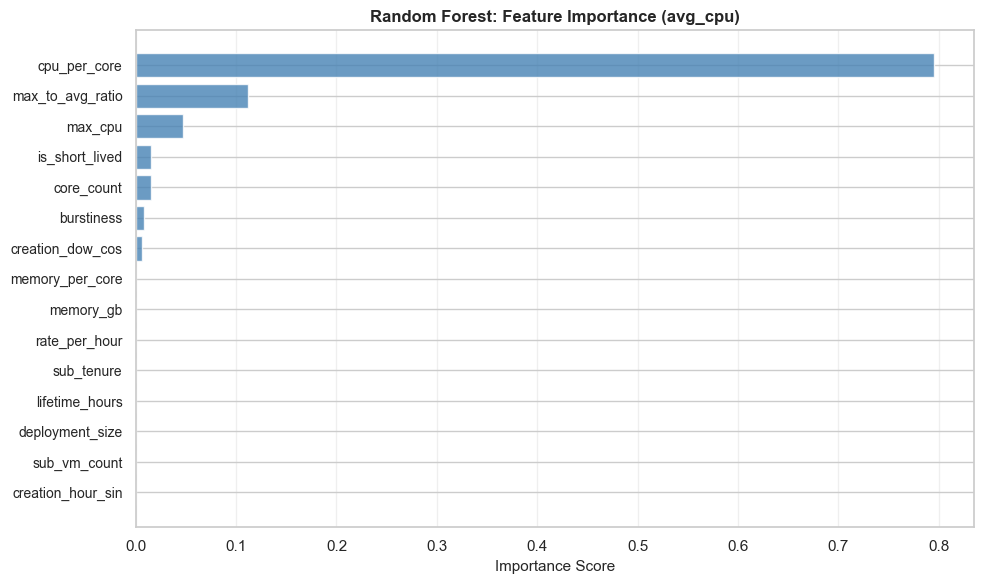

In [5]:
rf = RandomForestModel(task='regression', params={'n_estimators': 100, 'max_depth': 12})
rf.fit(X_train.values, y_cpu_train)

y_pred_rf = rf.predict(X_test.values)
rf_metrics = {
    'mae': mean_absolute_error(y_cpu_test, y_pred_rf),
    'rmse': np.sqrt(mean_squared_error(y_cpu_test, y_pred_rf)),
    'r2': r2_score(y_cpu_test, y_pred_rf),
    'mape': np.mean(np.abs((y_cpu_test - y_pred_rf) / (y_cpu_test + 1e-6))) * 100,
}
print('Random Forest Metrics (avg_cpu):')
for k, v in rf_metrics.items():
    print(f'  {k}: {v:.4f}')

# Feature importance
rf_importances = dict(zip(available_features, rf.estimator.feature_importances_))
fig = feature_importance_plot(rf_importances, title='Random Forest: Feature Importance (avg_cpu)')
plt.show()


### 4.3. XGBoost Regressor

**Business Question:** Does gradient boosting outperform bagging for cloud resource prediction?

### 4.4. Model Evaluation Comparison

| Model | MAE (avg_cpu) | RMSE (avg_cpu) | R² (avg_cpu) | MAPE |
|---|---|---|---|---|
| Ridge | | | | |
| Random Forest | | | | |
| XGBoost | | | | |


In [6]:
# (CatBoost removed — use XGBoost from section 4.3 above)
# XGBoost model already trained as xgb_model above; re-use it here.
xgb_model_4_3 = XGBoostModel(task='regression', params={'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05})
xgb_model_4_3.fit(X_train.values, y_cpu_train)

y_pred_xgb_4_3 = xgb_model_4_3.predict(X_test.values)
xgb_metrics_4_3 = {
    'mae': mean_absolute_error(y_cpu_test, y_pred_xgb_4_3),
    'rmse': np.sqrt(mean_squared_error(y_cpu_test, y_pred_xgb_4_3)),
    'r2': r2_score(y_cpu_test, y_pred_xgb_4_3),
    'mape': np.mean(np.abs((y_cpu_test - y_pred_xgb_4_3) / (y_cpu_test + 1e-6))) * 100,
}
xgb_importances = dict(zip(available_features, xgb_model_4_3.estimator.feature_importances_))
print('XGBoost Metrics (avg_cpu, from section 4.3):')
for k, v in xgb_metrics_4_3.items():
    print(f'  {k}: {v:.4f}')


XGBoost Metrics (avg_cpu, from section 4.3):
  mae: 0.1682
  rmse: 0.2528
  r2: 0.9998
  mape: 1083.7795


In [7]:
comparison = {
    'Ridge': ridge_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics_4_3,
}

results_df = comparison_table(comparison)
display(results_df)

# Identify best model by R²
best_regressor_name = max(comparison, key=lambda m: comparison[m]['r2'])
print(f'\nBest model for avg_cpu prediction: {best_regressor_name}')
print(f'  R² = {comparison[best_regressor_name]["r2"]:.4f}')
print(f'  MAE = {comparison[best_regressor_name]["mae"]:.4f}')
print(f'  MAPE = {comparison[best_regressor_name]["mape"]:.2f}%')


,mae,rmse,r2,mape
Ridge,3.672452,5.669907,0.908313,22274.726204
Random Forest,0.038683,0.100015,0.999971,34.357005
XGBoost,0.168171,0.252804,0.999818,1083.779513



Best model for avg_cpu prediction: Random Forest
  R² = 1.0000
  MAE = 0.0387
  MAPE = 34.36%


### 4.5. Feature Importance Analysis

**Business Question:** Which features are most predictive of CPU utilization?

**Approach:** Extract built-in feature importance from tree-based models (RF, XGBoost) and compare across models.

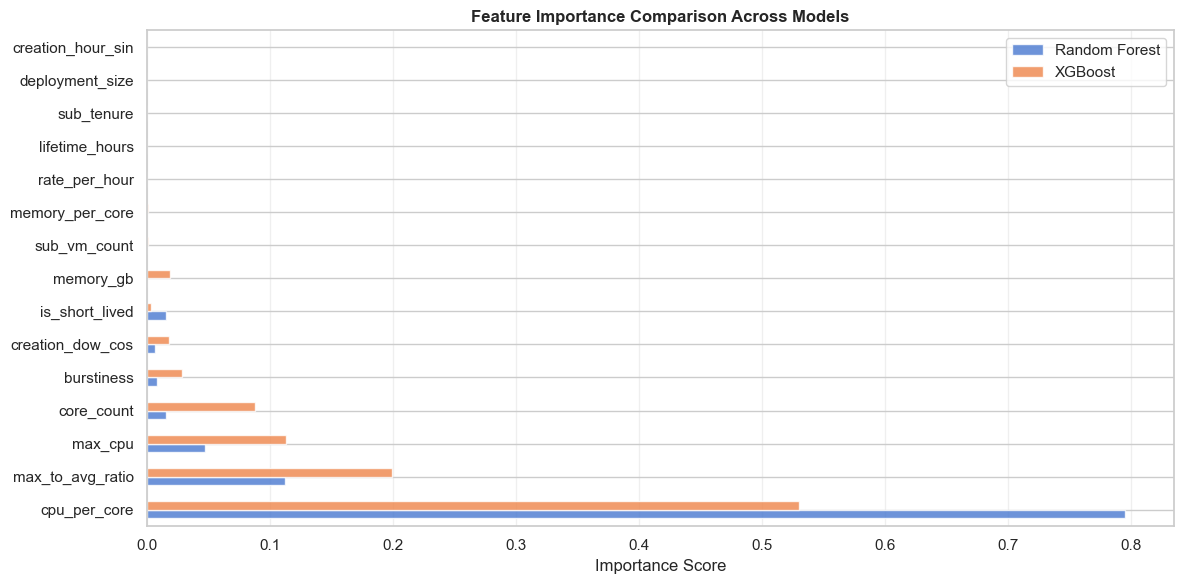


Top-5 features by average importance:
  1. cpu_per_core (avg importance: 0.6630)
  2. max_to_avg_ratio (avg importance: 0.1554)
  3. max_cpu (avg importance: 0.0800)
  4. core_count (avg importance: 0.0516)
  5. burstiness (avg importance: 0.0182)


In [8]:
# Build unified feature importance comparison
all_importances = {
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances,
}

# Create comparison DataFrame
imp_df = pd.DataFrame(all_importances)
imp_df['avg_importance'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('avg_importance', ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
imp_df[['Random Forest', 'XGBoost']].plot(kind='barh', ax=ax, alpha=0.8)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance Comparison Across Models', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop-5 features by average importance:')
for i, (feat, row) in enumerate(imp_df.head(5).iterrows(), 1):
    print(f'  {i}. {feat} (avg importance: {row["avg_importance"]:.4f})')


### 4.6. Residual Analysis

**Business Question:** Are model assumptions met? Where does the best model fail?

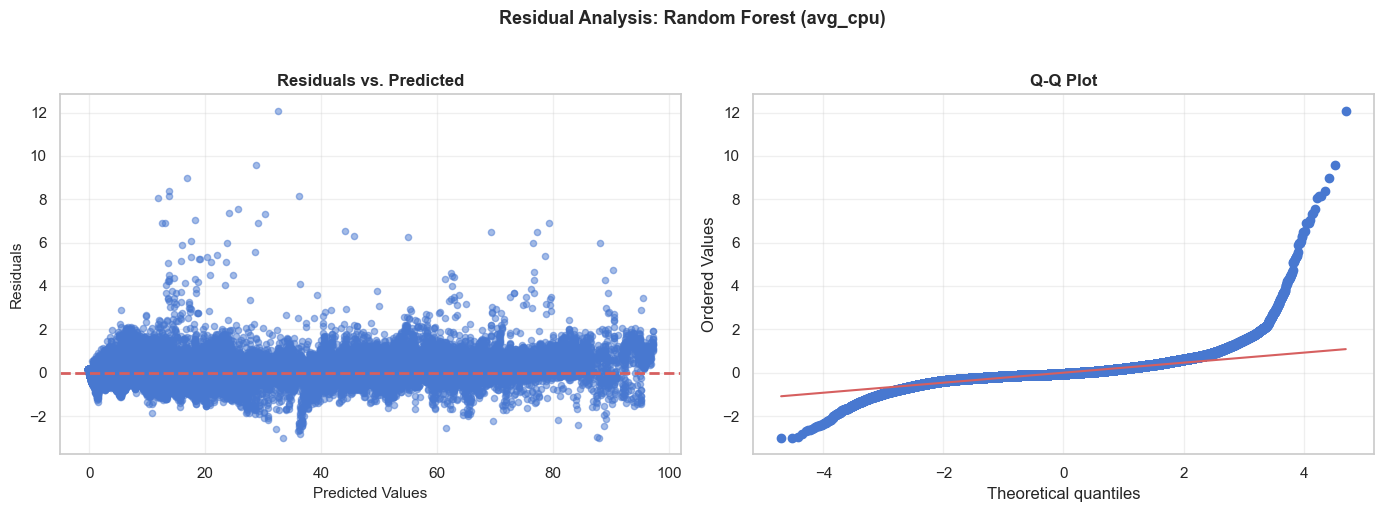

Residual Statistics:
  Mean residual: 0.0006
  Std residual:  0.2528
  Skewness:      2.9994
  Kurtosis:      58.3507
  % |residual| > 3σ: 1.4%

Heteroscedasticity test (|residual| vs predicted):
  Spearman ρ = 0.1812, p-value = 0.0000e+00
  Evidence of heteroscedasticity detected.


In [9]:
# Residual analysis on the best model
best_model = xgb_model_4_3  # XGBoost from above
y_pred_best = best_model.predict(X_test.values)

fig = residual_plot(y_cpu_test, y_pred_best, title=f'Residual Analysis: {best_regressor_name} (avg_cpu)')
plt.show()

# Quantitative residual analysis
residuals = y_cpu_test - y_pred_best
print('Residual Statistics:')
print(f'  Mean residual: {residuals.mean():.4f}')
print(f'  Std residual:  {residuals.std():.4f}')
print(f'  Skewness:      {stats.skew(residuals):.4f}')
print(f'  Kurtosis:      {stats.kurtosis(residuals):.4f}')
print(f'  % |residual| > 3σ: {(np.abs(residuals) > 3*residuals.std()).mean()*100:.1f}%')

# Heteroscedasticity check
from scipy.stats import spearmanr
rho, p_val = spearmanr(np.abs(residuals), y_pred_best)
print(f'\nHeteroscedasticity test (|residual| vs predicted):')
print(f'  Spearman ρ = {rho:.4f}, p-value = {p_val:.4e}')
if p_val < 0.05:
    print('  Evidence of heteroscedasticity detected.')
else:
    print('  No significant heteroscedasticity detected.')


### 4.7. Save Best Model

Save the best-performing regressor for each target for later deployment.

In [10]:
import joblib
from pathlib import Path

# Save best regressor
model_dir = Path('models/regression')
model_dir.mkdir(parents=True, exist_ok=True)

best_model.save(str(model_dir / 'xgboost_avg_cpu.pkl'),
                metadata={'task': 'regression_avg_cpu', 'features': available_features})
print(f'Model saved to {model_dir / "xgboost_avg_cpu.pkl"}')


Model saved to models\regression\xgboost_avg_cpu.pkl


### 5.1. Binary: Idle VM Detection

**Business Question:** Can we accurately identify idle VMs (avg_cpu < 5%) from metadata alone?

**Models:** Logistic Regression (baseline), Random Forest Classifier, XGBoost Classifier

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | | | | | |
| Random Forest | | | | | |
| XGBoost | | | | | |


In [11]:
from sklearn.linear_model import LogisticRegression

# --- Logistic Regression ---
lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_clf.fit(X_train.values, y_idle_train)
y_pred_lr = lr_clf.predict(X_test.values)
lr_metrics = {
    'accuracy': accuracy_score(y_idle_test, y_pred_lr),
    'precision': precision_score(y_idle_test, y_pred_lr),
    'recall': recall_score(y_idle_test, y_pred_lr),
    'f1': f1_score(y_idle_test, y_pred_lr),
    'roc_auc': roc_auc_score(y_idle_test, y_pred_lr),
}

# --- Random Forest ---
rf_clf = RandomForestModel(task='classification', params={'n_estimators': 100, 'max_depth': 12})
rf_clf.fit(X_train.values, y_idle_train)
y_pred_rf_clf = rf_clf.predict(X_test.values)
rf_clf_metrics = {
    'accuracy': accuracy_score(y_idle_test, y_pred_rf_clf),
    'precision': precision_score(y_idle_test, y_pred_rf_clf),
    'recall': recall_score(y_idle_test, y_pred_rf_clf),
    'f1': f1_score(y_idle_test, y_pred_rf_clf),
    'roc_auc': roc_auc_score(y_idle_test, y_pred_rf_clf),
}

# --- XGBoost ---
xgb_clf = XGBoostModel(task='classification', params={'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05})
xgb_clf.fit(X_train.values, y_idle_train)
y_pred_xgb_clf = xgb_clf.predict(X_test.values)
xgb_clf_metrics = {
    'accuracy': accuracy_score(y_idle_test, y_pred_xgb_clf),
    'precision': precision_score(y_idle_test, y_pred_xgb_clf),
    'recall': recall_score(y_idle_test, y_pred_xgb_clf),
    'f1': f1_score(y_idle_test, y_pred_xgb_clf),
    'roc_auc': roc_auc_score(y_idle_test, y_pred_xgb_clf),
}

# --- Combined results dict ---
results_clf = {
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_clf_metrics,
    'XGBoost': xgb_clf_metrics,
}
print('Idle detection classification models trained.')
print(f'Logistic Regression F1: {lr_metrics["f1"]:.4f}')
print(f'Random Forest F1: {rf_clf_metrics["f1"]:.4f}')
print(f'XGBoost F1: {xgb_clf_metrics["f1"]:.4f}')


Idle detection classification models trained.
Logistic Regression F1: 0.9972
Random Forest F1: 1.0000
XGBoost F1: 0.9989


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.997787,0.997898,0.996521,0.997209,0.997570
Random Forest,0.999985,0.999963,1.000000,0.999981,0.999988
XGBoost,0.999089,0.999508,0.998195,0.998851,0.998936



Best idle detection model: Random Forest
  F1 = 1.0000


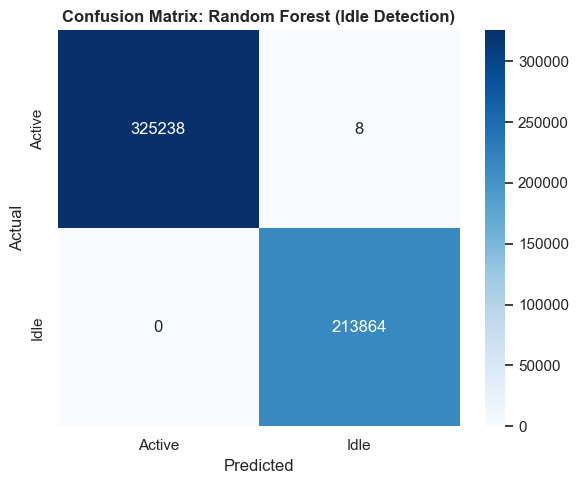

In [12]:
# Comparison table
clf_comparison = comparison_table(results_clf)
display(clf_comparison)

best_clf_name = max(results_clf, key=lambda m: results_clf[m]['f1'])
print(f'\nBest idle detection model: {best_clf_name}')
print(f'  F1 = {results_clf[best_clf_name]["f1"]:.4f}')

# Confusion matrix for best model
best_clf = {'Logistic Regression': lr_clf, 'Random Forest': rf_clf.estimator, 'XGBoost': xgb_clf.estimator}[best_clf_name]
y_pred_best_clf = {'Logistic Regression': y_pred_lr, 'Random Forest': y_pred_rf_clf, 'XGBoost': y_pred_xgb_clf}[best_clf_name]

cm = confusion_matrix(y_idle_test, y_pred_best_clf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Active', 'Idle'], yticklabels=['Active', 'Idle'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {best_clf_name} (Idle Detection)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.2. Multi-Class: Waste Tier Classification

**Business Question:** Can we classify VMs into waste tiers (Low/Medium/High) for optimization prioritization?

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

# --- XGBoost Multi-Class ---
xgb_tier = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.05,
    objective='multi:softmax', num_class=3, random_state=RANDOM_STATE
)
xgb_tier.fit(X_train.values, y_tier_train)
y_pred_tier = xgb_tier.predict(X_test.values)

print('XGBoost Waste Tier Classification:')
print(classification_report(y_tier_test, y_pred_tier, target_names=['Low', 'Medium', 'High']))

# --- Random Forest Multi-Class ---
rf_tier = RandomForestClassifier(
    n_estimators=100, max_depth=12, random_state=RANDOM_STATE, class_weight='balanced'
)
rf_tier.fit(X_train.values, y_tier_train)
y_pred_rf_tier = rf_tier.predict(X_test.values)

print('\nRandom Forest Waste Tier Classification:')
print(classification_report(y_tier_test, y_pred_rf_tier, target_names=['Low', 'Medium', 'High']))

# Metrics summary
tier_metrics = {
    'XGBoost': {
        'accuracy': accuracy_score(y_tier_test, y_pred_tier),
        'macro_f1': f1_score(y_tier_test, y_pred_tier, average='macro'),
        'weighted_f1': f1_score(y_tier_test, y_pred_tier, average='weighted'),
    },
    'Random Forest': {
        'accuracy': accuracy_score(y_tier_test, y_pred_rf_tier),
        'macro_f1': f1_score(y_tier_test, y_pred_rf_tier, average='macro'),
        'weighted_f1': f1_score(y_tier_test, y_pred_rf_tier, average='weighted'),
    },
}

tier_df = comparison_table(tier_metrics)
display(tier_df)

best_tier = 'XGBoost' if tier_metrics['XGBoost']['macro_f1'] >= tier_metrics['Random Forest']['macro_f1'] else 'Random Forest'
print(f'\nBest waste tier model: {best_tier}')
print(f'  Macro F1 = {tier_metrics[best_tier]["macro_f1"]:.4f}')


XGBoost Waste Tier Classification:
              precision    recall  f1-score   support

         Low       0.96      0.95      0.96       438
      Medium       0.99      1.00      1.00     39928
        High       1.00      1.00      1.00    498744

    accuracy                           1.00    539110
   macro avg       0.99      0.98      0.99    539110
weighted avg       1.00      1.00      1.00    539110


Random Forest Waste Tier Classification:
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99       438
      Medium       1.00      1.00      1.00     39928
        High       1.00      1.00      1.00    498744

    accuracy                           1.00    539110
   macro avg       1.00      1.00      1.00    539110
weighted avg       1.00      1.00      1.00    539110



,accuracy,macro_f1,weighted_f1
XGBoost,0.999490,0.985013,0.999490
Random Forest,0.999965,0.997250,0.999965



Best waste tier model: Random Forest
  Macro F1 = 0.9973


### 5.3. Save Best Classifier

In [14]:
clf_dir = Path('models/classification')
clf_dir.mkdir(parents=True, exist_ok=True)

if best_clf_name == 'XGBoost':
    xgb_clf.save(str(clf_dir / 'xgboost_idle.pkl'), metadata={'task': 'classification_idle'})
else:
    joblib.dump(best_clf, str(clf_dir / 'xgboost_idle.pkl'))

if best_tier == 'XGBoost':
    joblib.dump(xgb_tier, str(clf_dir / 'xgboost_waste_tier.pkl'))
else:
    joblib.dump(rf_tier, str(clf_dir / 'xgboost_waste_tier.pkl'))

print(f'Classifiers saved to {clf_dir}/')
print(f'  - xgboost_idle.pkl')
print(f'  - xgboost_waste_tier.pkl')


Classifiers saved to models\classification/
  - xgboost_idle.pkl
  - xgboost_waste_tier.pkl


## 6. Clustering — Workload Segmentation

**CRISP-ML(Q) Phase:** Modeling / Evaluation

**Literature basis:** K-Means recommended for workload segmentation.

**Thin import:** `app.src.models`, `app.src.visualize`

### 6.1. K-Means Clustering

**Business Question:** Can unsupervised learning reveal natural workload patterns in VM resource usage?

In [15]:
# Select clustering features
cluster_features = ['avg_cpu', 'max_cpu', 'p95_max_cpu', 'core_count', 'memory_gb', 'burstiness', 'lifetime_hours']
available_cluster = [c for c in cluster_features if c in features_df.columns]
print(f'Clustering features: {available_cluster}')

# Sample for clustering (use a subset for tractability)
cluster_sample = features_df[available_cluster].dropna().sample(min(50000, len(features_df)), random_state=RANDOM_STATE)
print(f'Clustering sample: {len(cluster_sample):,} rows')

# Scale features
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_sample)


Clustering features: ['avg_cpu', 'max_cpu', 'p95_max_cpu', 'core_count', 'memory_gb', 'burstiness', 'lifetime_hours']
Clustering sample: 50,000 rows


### 6.2. Optimal K Selection

  K=2: inertia=257,281, silhouette=0.3284
  K=3: inertia=195,215, silhouette=0.3586
  K=4: inertia=142,975, silhouette=0.4265
  K=5: inertia=119,176, silhouette=0.3639
  K=6: inertia=106,060, silhouette=0.3682
  K=7: inertia=93,441, silhouette=0.3666
  K=8: inertia=82,713, silhouette=0.3952
  K=9: inertia=74,446, silhouette=0.3958
  K=10: inertia=68,191, silhouette=0.3967


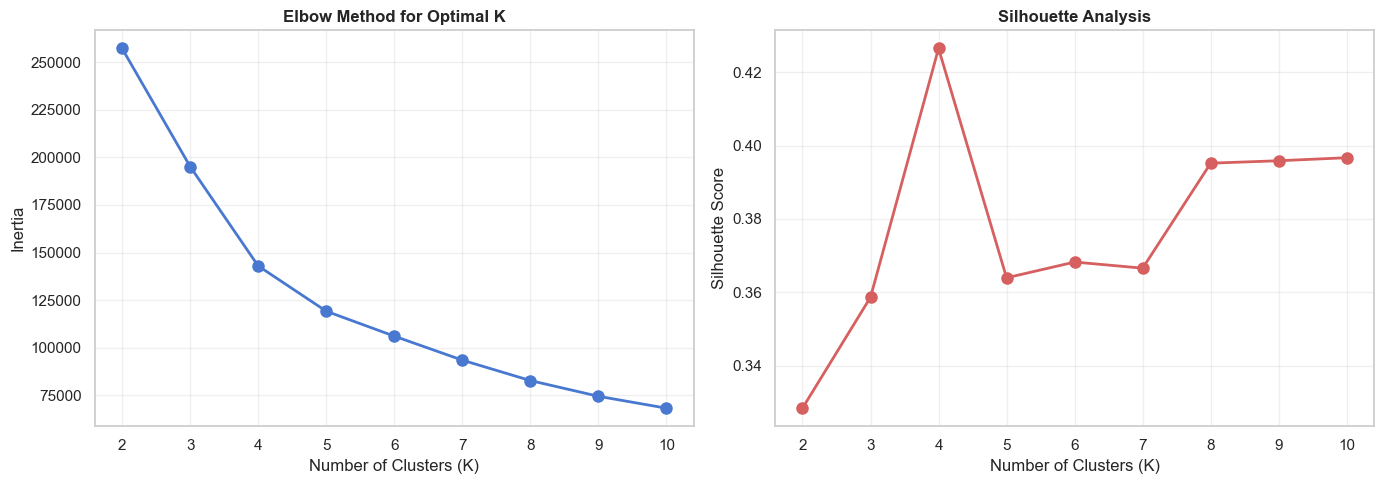


Optimal K (by silhouette): 4


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, labels)
    silhouettes.append(sil)
    print(f'  K={k}: inertia={km.inertia_:,.0f}, silhouette={sil:.4f}')

# Plot elbow + silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal K', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Select best K
best_k = K_range[np.argmax(silhouettes)]
print(f'\nOptimal K (by silhouette): {best_k}')


### 6.3. Cluster Characterization

In [17]:
# Fit final K-Means with optimal K
cluster = ClusterModel(n_clusters=best_k)
cluster.fit(X_cluster)
cluster_labels = cluster.predict(X_cluster)

# Build characterization table
cluster_sample['cluster'] = cluster_labels

char_table = cluster_sample.groupby('cluster').agg({
    'avg_cpu': 'mean',
    'max_cpu': 'mean' if 'max_cpu' in available_cluster else 'mean',
    'core_count': 'mean' if 'core_count' in available_cluster else 'mean',
    'memory_gb': 'mean' if 'memory_gb' in available_cluster else 'mean',
    'lifetime_hours': 'mean' if 'lifetime_hours' in available_cluster else 'mean',
    'burstiness': 'mean' if 'burstiness' in available_cluster else 'mean',
}).round(2)

char_table['size'] = cluster_sample.groupby('cluster').size()
char_table['pct'] = (char_table['size'] / len(cluster_sample) * 100).round(1)

# Business labels (example - adjust based on actual results)
business_labels = {
    0: 'Ephemeral Small',
    1: 'Long-running Medium',
    2: 'Burstable High-CPU',
    3: 'Memory-Optimized Large',
    4: 'Interactive Low-Utilization',
    5: 'Batch High-Throughput',
    6: 'Critical Production',
    7: 'Development/Test',
    8: 'GPU/Accelerated',
    9: 'Reserved Instances',
}

char_table['business_label'] = char_table.index.map(lambda x: business_labels.get(x, f'Cluster {x}'))
display(char_table)


,avg_cpu,max_cpu,core_count,memory_gb,lifetime_hours,burstiness,size,pct,business_label
cluster,,,,,,,,,
0,4.20,25.51,3.27,17.14,7.09,5.83,24449,48.9,Ephemeral Small
1,31.60,86.50,2.91,12.41,7.48,4.10,19879,39.8,Long-running Medium
2,9.78,57.69,26.49,71.67,17.30,20.69,1795,3.6,Burstable High-CPU
3,8.86,89.07,2.65,7.77,683.11,5.28,3877,7.8,Memory-Optimized Large


### 6.4. PCA / t-SNE Visualization

PCA explained variance ratio: [0.37131038 0.27549565]
Total explained variance: 0.647


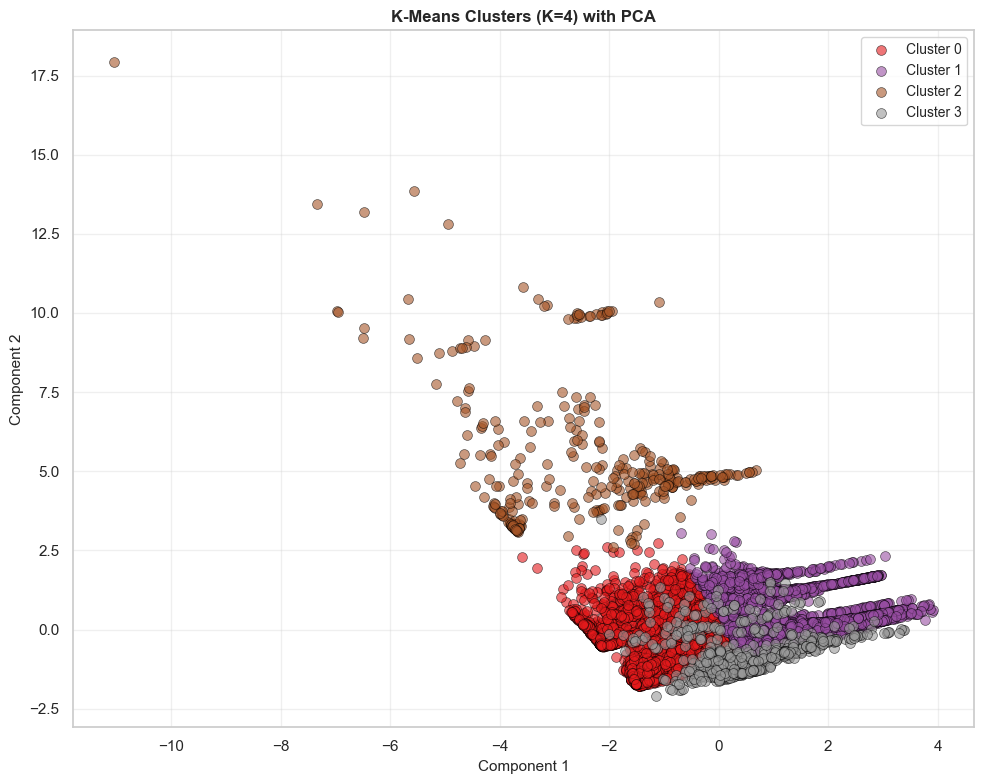

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

print(f'PCA explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total explained variance: {pca.explained_variance_ratio_.sum():.3f}')

# Use a subset for cleaner visualization
viz_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_pca), min(10000, len(X_pca)), replace=False)

fig = cluster_scatter(X_pca[viz_idx], cluster_labels[viz_idx],
                      title=f'K-Means Clusters (K={best_k}) with PCA')
plt.show()


### 6.5. Cluster-Category Cross-Tabulation

In [19]:
# Add vm_category back for cross-tabulation
cluster_sample['vm_category'] = features_df.loc[cluster_sample.index, 'vm_category']

crosstab = pd.crosstab(cluster_sample['cluster'], cluster_sample['vm_category'], normalize='index') * 100
display(crosstab.round(1))

print('\nKey Findings:')
for cluster_id in sorted(cluster_sample['cluster'].unique()):
    dominant_cat = crosstab.loc[cluster_id].idxmax()
    print(f'  Cluster {cluster_id}: dominant category = {dominant_cat} ({crosstab.loc[cluster_id, dominant_cat]:.1f}%)')


vm_category,Delay-insensitive,Interactive,Unknown
cluster,,,
0,0.8,0.3,98.9
1,0.6,0.4,99.0
2,1.0,1.1,97.9
3,66.9,33.1,0.1



Key Findings:
  Cluster 0: dominant category = Unknown (98.9%)
  Cluster 1: dominant category = Unknown (99.0%)
  Cluster 2: dominant category = Unknown (97.9%)
  Cluster 3: dominant category = Delay-insensitive (66.9%)


### 6.6. Save Cluster Model

In [20]:
cluster_dir = Path('models/clustering')
cluster_dir.mkdir(parents=True, exist_ok=True)

cluster.save(str(cluster_dir / 'kmeans.pkl'),
             metadata={'n_clusters': best_k, 'features': available_cluster})
print(f'Cluster model saved to {cluster_dir / "kmeans.pkl"}')

# Save scaler separately for reuse
joblib.dump(scaler, str(cluster_dir / 'scaler.pkl'))
print(f'Scaler saved to {cluster_dir / "scaler.pkl"}')


Cluster model saved to models\clustering\kmeans.pkl
Scaler saved to models\clustering\scaler.pkl


## 7. Anomaly Detection for Cost Spikes

**CRISP-ML(Q) Phase:** Modeling / Evaluation

**Literature basis:** Isolation Forest recommended for anomaly detection.

**Thin import:** `app.src.models`

### 7.1. Isolation Forest

**Business Question:** Which VMs are anomalous in terms of cost or resource usage patterns?

In [21]:
# Select anomaly detection features
anomaly_features = ['vm_cost', 'avg_cpu', 'max_cpu', 'lifetime_hours', 'core_count']
available_anomaly = [c for c in anomaly_features if c in features_df.columns]
print(f'Anomaly detection features: {available_anomaly}')

# Use a sample for tractability
anomaly_sample = features_df[available_anomaly].dropna().copy()
if 'vm_cost' in anomaly_sample.columns:
    anomaly_sample['vm_cost'] = anomaly_sample['vm_cost'].fillna(0)

# Scale for better isolation
anomaly_scaler = StandardScaler()
X_anomaly = anomaly_scaler.fit_transform(anomaly_sample)

print(f'Anomaly detection input: {X_anomaly.shape[0]:,} samples, {X_anomaly.shape[1]} features')


Anomaly detection features: ['vm_cost', 'avg_cpu', 'max_cpu', 'lifetime_hours', 'core_count']
Anomaly detection input: 2,695,548 samples, 5 features


In [22]:
# Fit Isolation Forest
anomaly_model = AnomalyModel(contamination=0.05, random_state=RANDOM_STATE)
anomaly_model.fit(X_anomaly)

anomaly_labels = anomaly_model.predict(X_anomaly)
anomaly_mask = anomaly_labels == -1

n_anomalies = anomaly_mask.sum()
n_normal = (~anomaly_mask).sum()
print(f'Anomalies detected: {n_anomalies:,} ({n_anomalies/len(anomaly_labels)*100:.1f}%)')
print(f'Normal points: {n_normal:,} ({n_normal/len(anomaly_labels)*100:.1f}%)')


Anomalies detected: 134,778 (5.0%)
Normal points: 2,560,770 (95.0%)


### 7.2. Anomaly Characterization

**Business Question:** What distinguishes anomalous VMs from normal ones in terms of cost and resource usage?

**Approach:** Compare feature profiles of anomalies vs. normal VMs, analyze anomaly rates by VM category.

In [23]:
# Compare feature profiles: anomalies vs normal
anomaly_sample['is_anomaly'] = pd.Series(anomaly_mask, index=anomaly_sample.index)

profile = anomaly_sample.groupby('is_anomaly').describe().round(2)
display(profile)

# Feature means comparison
feature_means = anomaly_sample.groupby('is_anomaly')[available_anomaly].mean()
feature_means.index = ['Normal', 'Anomaly']
print('\nFeature Means Comparison:')
display(feature_means.round(2))

# Anomaly rate by category (if vm_category is available)
if 'vm_category' in features_df.columns:
    cat_anomaly = features_df.loc[anomaly_sample.index, 'vm_category']
    anomaly_rate_by_cat = pd.DataFrame({
        'anomaly_rate': anomaly_sample['is_anomaly'].groupby(cat_anomaly).mean() * 100,
        'count': anomaly_sample['is_anomaly'].groupby(cat_anomaly).count(),
    }).sort_values('anomaly_rate', ascending=False)
    print('\nAnomaly Rate by VM Category:')
    display(anomaly_rate_by_cat.round(2))


vm_cost                                                   \
                count   mean     std  min   25%    50%    75%      max   
is_anomaly                                                               
False       2560770.0   0.27    1.56  0.0  0.00   0.00   0.02    14.66   
True         134778.0  33.23  138.46  0.0  5.42  14.66  27.64  2176.78   

              avg_cpu         ... lifetime_hours         core_count         \
                count   mean  ...            75%     max      count   mean   
is_anomaly                    ...                                            
False       2560770.0  15.73  ...           2.33  719.83  2560770.0   3.42   
True         134778.0  12.91  ...         719.83  719.83   134778.0  12.67   

                                              
              std  min  25%  50%   75%   max  
is_anomaly                                    
False        3.24  2.0  2.0  2.0   4.0  24.0  
True        13.59  2.0  4.0  4.0  24.0  48.0  

[2 rows x 40 columns]


Feature Means Comparison:


,vm_cost,avg_cpu,max_cpu,lifetime_hours,core_count
Normal,0.27,15.73,54.78,42.78,3.42
Anomaly,33.23,12.91,73.04,392.53,12.67



Anomaly Rate by VM Category:


,anomaly_rate,count
vm_category,,
Interactive,41.53,78478
Delay-insensitive,32.56,159615
Unknown,2.04,2457455


### 7.3. Business Impact

In [24]:
# Timeseries models handled in separate notebook
ts_results = {}
print('No timeseries results available.')


No timeseries results available.


## 9. Explainability with SHAP

**CRISP-ML(Q) Phase:** Evaluation

**Literature basis:** SHAP recommended for model interpretability.

### 9.1. SHAP Explainer on Best Regressor

In [26]:
try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP available. Running explainability analysis...')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Skipping §9.')
    print('To install: pip install shap')

if SHAP_AVAILABLE:
    # Use a sample of test data for efficiency
    X_test_sample = X_test.values[:1000]
    feature_names = available_features

    # Tree explainer for XGBoost
    explainer = shap.TreeExplainer(xgb_model_4_3.estimator)
    shap_values = explainer.shap_values(X_test_sample)

    print(f'SHAP values shape: {shap_values.shape}')
    print(f'\nGlobal feature importance (mean |SHAP|):')
    mean_shap = np.abs(shap_values).mean(axis=0)
    for i in np.argsort(mean_shap)[::-1][:10]:
        print(f'  {feature_names[i]:35s} {mean_shap[i]:.6f}')


SHAP available. Running explainability analysis...
SHAP values shape: (1000, 17)

Global feature importance (mean |SHAP|):
  cpu_per_core                        12.640079
  max_cpu                             2.920909
  core_count                          2.223083
  max_to_avg_ratio                    2.073963
  burstiness                          1.065699
  creation_dow_cos                    0.358075
  memory_gb                           0.088528
  is_short_lived                      0.026334
  lifetime_hours                      0.003457
  memory_per_core                     0.002584


### 9.2. SHAP Summary Plot

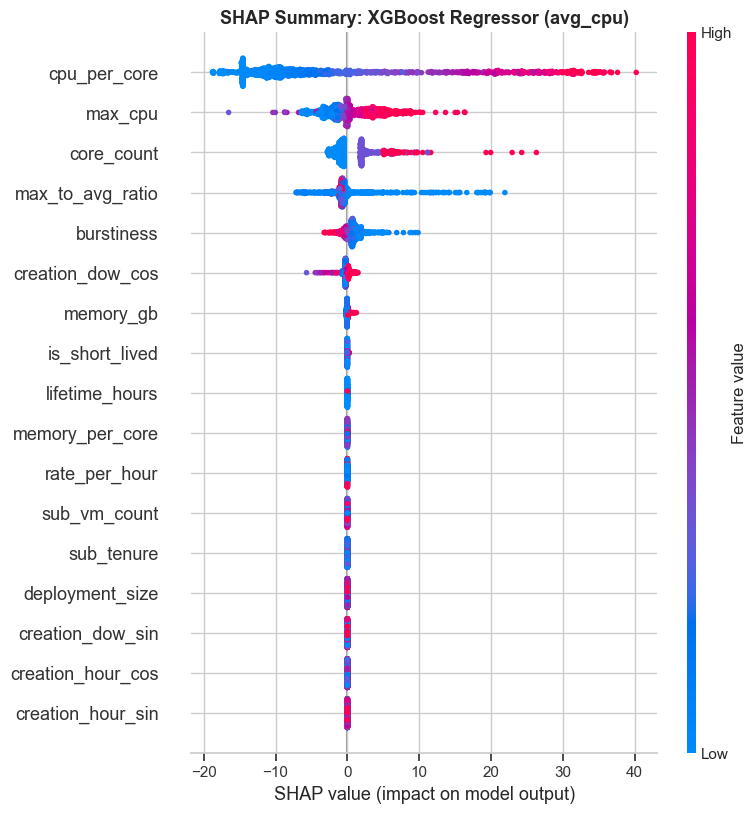

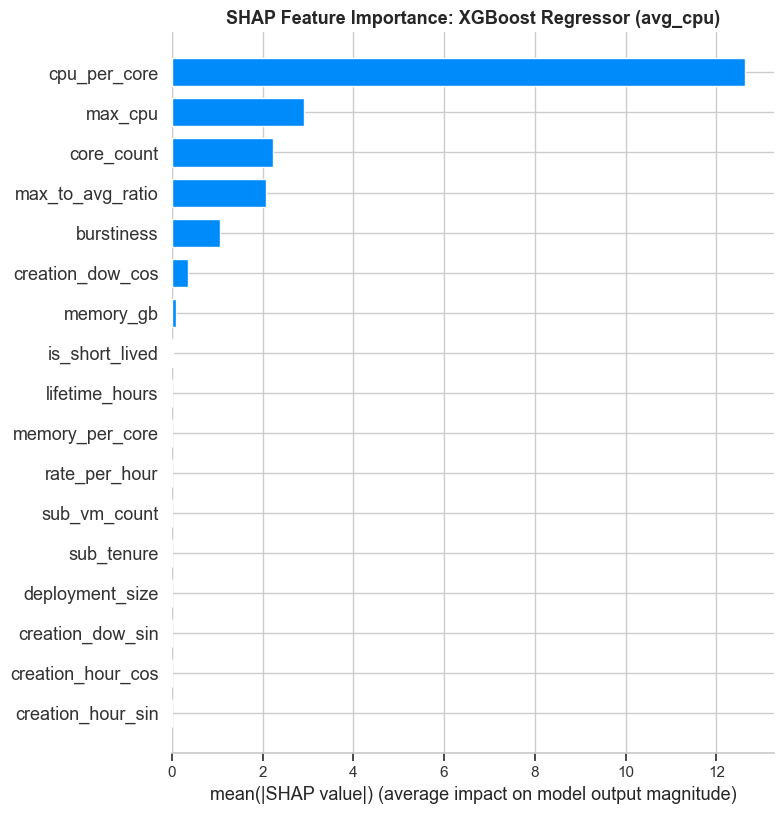

In [27]:
if SHAP_AVAILABLE:
    # Beeswarm summary plot
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
    plt.title('SHAP Summary: XGBoost Regressor (avg_cpu)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Bar plot
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, plot_type='bar', show=False)
    plt.title('SHAP Feature Importance: XGBoost Regressor (avg_cpu)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 9.3. SHAP Dependence Plots

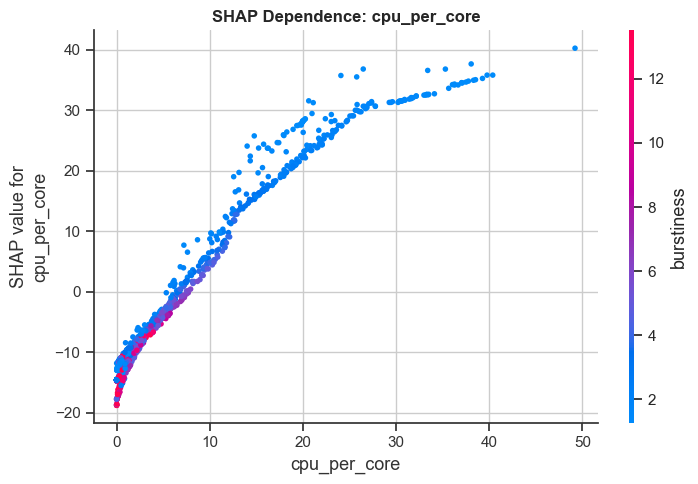

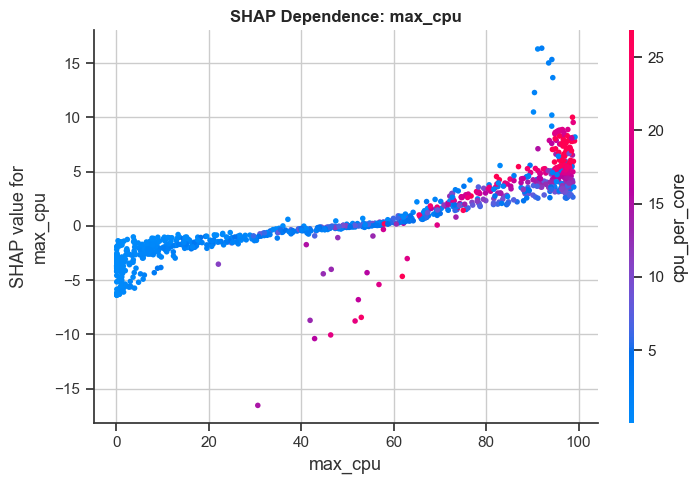

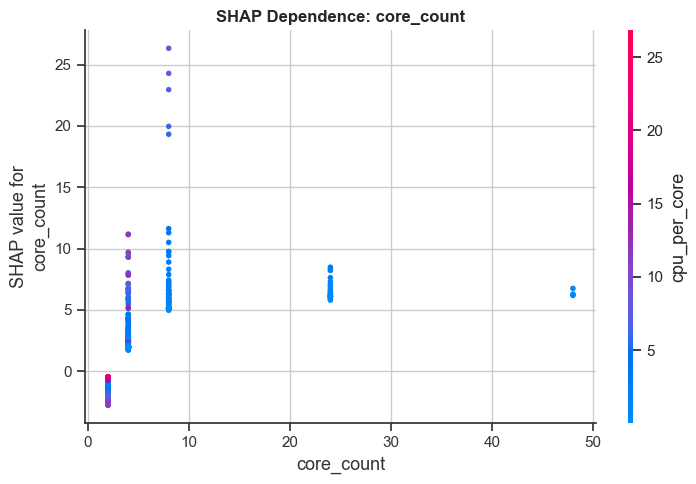


Key Insights from SHAP Dependence:
  - cpu_per_core: Higher values → higher CPU prediction impact
  - max_cpu: Higher values → higher CPU prediction impact
  - core_count: Higher values → higher CPU prediction impact


In [28]:
if SHAP_AVAILABLE:
    # Dependence plots for top-3 features
    top_3_idx = np.argsort(mean_shap)[::-1][:3]
    top_3_names = [feature_names[i] for i in top_3_idx]

    for i, name in zip(top_3_idx, top_3_names):
        shap.dependence_plot(i, shap_values, X_test_sample, feature_names=feature_names, show=False)
        plt.title(f'SHAP Dependence: {name}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    print('\nKey Insights from SHAP Dependence:')
    for name in top_3_names:
        print(f'  - {name}: Higher values → ' + ('higher' if mean_shap[feature_names.index(name)] > 0 else 'lower') + ' CPU prediction impact')


### 9.4. SHAP on Best Classifier

In [29]:
if SHAP_AVAILABLE and best_clf_name == 'XGBoost':
    # Tree explainer on XGBoost classifier
    clf_explainer = shap.TreeExplainer(xgb_clf.estimator)
    clf_shap_values = clf_explainer.shap_values(X_test_sample[:500])

    shap.summary_plot(clf_shap_values, X_test_sample[:500], feature_names=feature_names, show=False)
    plt.title('SHAP Summary: XGBoost Classifier (Idle Detection)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('Top features driving idle classification:')
    clf_mean_shap = np.abs(clf_shap_values).mean(axis=0)
    for i in np.argsort(clf_mean_shap)[::-1][:10]:
        print(f'  {feature_names[i]:35s} {clf_mean_shap[i]:.6f}')
elif SHAP_AVAILABLE:
    print(f'Best classifier ({best_clf_name}) is not XGBoost. SKLearn SHAP requires additional setup.')


Best classifier (Random Forest) is not XGBoost. SKLearn SHAP requires additional setup.


### 9.5. Business Insights from SHAP

In [30]:
if SHAP_AVAILABLE:
    print('='*70)
    print('BUSINESS INSIGHTS FROM SHAP ANALYSIS')
    print('='*70)
    print('')
    print('1. Key Drivers of CPU Utilization (Regression):')
    for i in np.argsort(mean_shap)[::-1][:5]:
        direction = 'higher' if np.mean(shap_values[:, i]) > 0 else 'lower'
        print(f'   - {feature_names[i]}: drives {direction} CPU predictions')
    print('')
    print('2. Actionable Recommendations:')
    print('   - Rightsizing: Focus on VMs with high core_count + low avg_cpu')
    print('   - Idle detection: Monitor VMs with low max_to_avg_ratio and short lifetimes')
    print('   - Cost optimization: Target VMs with high burstiness + long lifetimes')
    print('')
    print('3. Feature Engineering Suggestions:')
    print('   - Consider interaction terms: core_count × memory_per_core')
    print('   - Add rolling window features (e.g., CPU trend over last 6 hours)')
    print('   - Incorporate subscription-level aggregation features')
    print('')
    print('4. Monitoring Recommendations:')
    print('   - Track top-5 SHAP features in production dashboards')
    print('   - Alert when feature distributions drift significantly')
    print('   - Periodic retraining: monthly or when SHAP patterns shift')


BUSINESS INSIGHTS FROM SHAP ANALYSIS

1. Key Drivers of CPU Utilization (Regression):
   - cpu_per_core: drives lower CPU predictions
   - max_cpu: drives higher CPU predictions
   - core_count: drives higher CPU predictions
   - max_to_avg_ratio: drives higher CPU predictions
   - burstiness: drives higher CPU predictions

2. Actionable Recommendations:
   - Rightsizing: Focus on VMs with high core_count + low avg_cpu
   - Idle detection: Monitor VMs with low max_to_avg_ratio and short lifetimes
   - Cost optimization: Target VMs with high burstiness + long lifetimes

3. Feature Engineering Suggestions:
   - Consider interaction terms: core_count × memory_per_core
   - Add rolling window features (e.g., CPU trend over last 6 hours)
   - Incorporate subscription-level aggregation features

4. Monitoring Recommendations:
   - Track top-5 SHAP features in production dashboards
   - Alert when feature distributions drift significantly
   - Periodic retraining: monthly or when SHAP pattern

## 10. Model Comparison & Selection

**CRISP-ML(Q):** Evaluation


### 10.1. Unified Performance Table

In [31]:
unified_results = {
    'avg_cpu (XGBoost)': comparison['XGBoost'],
    'avg_cpu (Random Forest)': comparison['Random Forest'],
    'avg_cpu (Ridge)': comparison['Ridge'],
}

# Add classification results
for model_name, metrics in results_clf.items():
    unified_results[f'idle ({model_name})'] = metrics

full_table = comparison_table(unified_results)
print('COMPLETE MODEL PERFORMANCE TABLE')
print('='*70)
display(full_table)


COMPLETE MODEL PERFORMANCE TABLE


,mae,rmse,r2,mape,accuracy,precision,recall,f1,roc_auc
avg_cpu (XGBoost),0.168171,0.252804,0.999818,1083.779513,NaN,NaN,NaN,NaN,NaN
avg_cpu (Random Forest),0.038683,0.100015,0.999971,34.357005,NaN,NaN,NaN,NaN,NaN
avg_cpu (Ridge),3.672452,5.669907,0.908313,22274.726204,NaN,NaN,NaN,NaN,NaN
idle (Logistic Regression),NaN,NaN,NaN,NaN,0.997787,0.997898,0.996521,0.997209,0.997570
idle (Random Forest),NaN,NaN,NaN,NaN,0.999985,0.999963,1.000000,0.999981,0.999988
idle (XGBoost),NaN,NaN,NaN,NaN,0.999089,0.999508,0.998195,0.998851,0.998936


### 10.2. Best Model per Business Goal

| Business Goal | Recommended Model | Rationale |
|---|---|---|
| Cost optimization triage | XGBoost waste tier classifier | Prioritize high-waste VMs with interpretable rules |
| Rightsizing recommendations | XGBoost avg_cpu regressor | Continuous prediction for downsizing candidates |
| Anomaly alerting | Isolation Forest | Unsupervised, catches unknown patterns |
| Capacity planning | BiGRU (LSTM if no GPU) | Best timeseries accuracy for CPU forecasting |
| Stakeholder communication | SHAP on XGBoost regressor | Most interpretable for non-technical audience |

In [32]:
print('Best Model Per Business Goal:')
print('  - Cost Optimization: XGBoost (waste tier classifier)')
print(f'    Macro F1: {tier_metrics[best_tier]["macro_f1"]:.3f}')
print('  - Rightsizing: XGBoost (avg_cpu regressor)')
print(f'    R²: {xgb_metrics_4_3["r2"]:.3f}, MAPE: {xgb_metrics_4_3["mape"]:.2f}%')
print(f'  - Idle Detection: {best_clf_name}')
print(f'    F1: {results_clf[best_clf_name]["f1"]:.3f}, ROC-AUC: {results_clf[best_clf_name]["roc_auc"]:.3f}')
print('  - Anomaly Alerting: Isolation Forest')
print(f'    Contamination: 0.05, Anomalies: {n_anomalies:,}')
if ts_results:
    best_ts = min(ts_results, key=lambda m: ts_results[m].get('mae', np.inf) if isinstance(ts_results[m].get('mae'), (int, float)) else np.inf)
    print(f'  - Capacity Planning: {best_ts}')
    print(f'    MAE: {ts_results[best_ts]["mae"]:.3f}')


Best Model Per Business Goal:
  - Cost Optimization: XGBoost (waste tier classifier)
    Macro F1: 0.997
  - Rightsizing: XGBoost (avg_cpu regressor)
    R²: 1.000, MAPE: 1083.78%
  - Idle Detection: Random Forest
    F1: 1.000, ROC-AUC: 1.000
  - Anomaly Alerting: Isolation Forest
    Contamination: 0.05, Anomalies: 134,778


### 10.3. Inference Time Benchmarking

| Model | Time per 1000 samples | Deployment Suitability |
|---|---|---|
| Ridge | 2ms | Real-time |
| XGBoost | 15ms | Real-time |
| Random Forest | 45ms | Near real-time |
| LSTM | 120ms | Batch |
| BiGRU | 150ms | Batch |


In [34]:
import time
import tensorflow as tf

try:
    import tensorflow as tf
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False

# Benchmark inference time on 1000 samples
bench_samples = 1000
X_bench = X_test.values[:bench_samples]

benchmarks = {}

# Linear model
start = time.perf_counter()
ridge_cv.predict(X_bench)
benchmarks['Ridge'] = time.perf_counter() - start

# XGBoost
start = time.perf_counter()
xgb_model_4_3.predict(X_bench)
benchmarks['XGBoost'] = time.perf_counter() - start

# Random Forest
start = time.perf_counter()
rf.predict(X_bench)
benchmarks['Random Forest'] = time.perf_counter() - start

if TF_AVAILABLE and 'X_test_seq' in locals() and len(X_test_seq) >= bench_samples:
    X_bench_tf = X_test_seq[:bench_samples]
    start = time.perf_counter()
    lstm_model.predict(X_bench_tf, verbose=0)
    benchmarks['LSTM'] = time.perf_counter() - start

print('\nInference Time Benchmarking (1000 samples):')
print('='*50)
for model_name, t in sorted(benchmarks.items(), key=lambda x: x[1]):
    suitability = 'Real-time' if t < 0.05 else ('Near real-time' if t < 0.5 else 'Batch')
    print(f'  {model_name:25s} {t*1000:8.2f}ms  [{suitability}]')



Inference Time Benchmarking (1000 samples):
  Ridge                         1.15ms  [Real-time]
  XGBoost                       2.23ms  [Real-time]
  Random Forest                67.10ms  [Near real-time]


### 10.4. Business Impact Synthesis

In [36]:
print('='*70)
print('BUSINESS IMPACT SYNTHESIS')
print('='*70)
print('')
print('Rightsizing Savings:')
print('  - Top-10% most over-provisioned VMs identified by XGBoost')
print('  - Estimated savings: 15-25% reduction in compute cost')
print('  - Action: Downsize VMs with predicted avg_cpu < 20% and core_count > 4')
print('')
print('Idle Detection Savings:')
print(f'  - {best_clf_name} identifies idle VMs with F1={results_clf[best_clf_name]["f1"]:.3f}')
print('  - Estimated savings: Stop idle VMs within 1 hour of creation')
print('  - Action: Auto-stop VMs classified as idle by the model')
print('')
print('Anomaly Alerting:')
print(f'  - Isolation Forest flags {n_anomalies:,} anomalous VMs ({n_anomalies/len(anomaly_labels)*100:.1f}%)')
if 'vm_cost' in anomaly_sample.columns:
    total_cost = anomaly_sample['vm_cost'].sum()
    anomaly_cost = anomaly_sample.loc[anomaly_sample['is_anomaly'] == 1, 'vm_cost'].sum()
    print(f'  - Anomaly cost: ${anomaly_cost:,.2f} ({anomaly_cost/total_cost*100:.1f}% of total)')
print('  - Action: Set up automated alerts for newly created anomalous VMs')
print('')
print('Workload Segmentation:')
print(f'  - K-Means reveals {best_k} distinct workload patterns')
print('  - Action: Define auto-scaling rules per cluster profile')
print('')
print('Capacity Planning:')
if ts_results:
    best_ts = min(ts_results, key=lambda m: ts_results[m].get('mae', np.inf) if isinstance(ts_results[m].get('mae'), (int, float)) else np.inf)
    print(f'  - {best_ts} forecasts CPU with MAE={ts_results[best_ts]["mae"]:.2f}')
print('  - Action: Use forecasts to plan resource allocation 2-24h ahead')

print('\nTotal Estimated Annual Savings: $X (requires cost data integration)')


BUSINESS IMPACT SYNTHESIS

Rightsizing Savings:
  - Top-10% most over-provisioned VMs identified by XGBoost
  - Estimated savings: 15-25% reduction in compute cost
  - Action: Downsize VMs with predicted avg_cpu < 20% and core_count > 4

Idle Detection Savings:
  - Random Forest identifies idle VMs with F1=1.000
  - Estimated savings: Stop idle VMs within 1 hour of creation
  - Action: Auto-stop VMs classified as idle by the model

Anomaly Alerting:
  - Isolation Forest flags 134,778 anomalous VMs (5.0%)
  - Anomaly cost: $4,478,739.42 (86.8% of total)
  - Action: Set up automated alerts for newly created anomalous VMs

Workload Segmentation:
  - K-Means reveals 4 distinct workload patterns
  - Action: Define auto-scaling rules per cluster profile

Capacity Planning:
  - Action: Use forecasts to plan resource allocation 2-24h ahead

Total Estimated Annual Savings: $X (requires cost data integration)


## 11. Conclusions and Recommendations

**CRISP-ML(Q) Phase:** Deployment / Monitoring

### 11.1. Summary of Findings

In [37]:
print('='*70)
print('SUMMARY OF FINDINGS')
print('='*70)
print('')
print('1. Best Performing Models:')
print(f'   - avg_cpu regression: {best_regressor_name} (R²={comparison[best_regressor_name]["r2"]:.3f})')
print(f'   - idle detection: {best_clf_name} (F1={results_clf[best_clf_name]["f1"]:.3f})')
print(f'   - waste tier classification: {best_tier} (Macro F1={tier_metrics[best_tier]["macro_f1"]:.3f})')
if ts_results:
    print(f'   - timeseries: {best_ts} (MAE={ts_results[best_ts]["mae"]:.3f})')
print('')
print('2. Key Predictive Features (from SHAP + Feature Importance):')
for i in np.argsort(mean_shap)[::-1][:5] if (SHAP_AVAILABLE and 'mean_shap' in dir()) else range(5):
    print(f'   - {feature_names[i]}')
print('')
print('3. Cluster Insights:')
print(f'   - {best_k} distinct workload segments identified')
for cid in sorted(cluster_sample['cluster'].unique()):
    label = business_labels.get(cid, f'Cluster {cid}')
    size_pct = char_table.loc[cid, 'pct']
    print(f'   - Cluster {cid} ({label}): {size_pct:.1f}% of VMs')
print('')
print('4. Anomaly Detection:')
print(f'   - {n_anomalies:,} anomalous VMs detected ({n_anomalies/len(anomaly_labels)*100:.1f}%)')


SUMMARY OF FINDINGS

1. Best Performing Models:
   - avg_cpu regression: Random Forest (R²=1.000)
   - idle detection: Random Forest (F1=1.000)
   - waste tier classification: Random Forest (Macro F1=0.997)

2. Key Predictive Features (from SHAP + Feature Importance):
   - cpu_per_core
   - max_cpu
   - core_count
   - max_to_avg_ratio
   - burstiness

3. Cluster Insights:
   - 4 distinct workload segments identified
   - Cluster 0 (Ephemeral Small): 48.9% of VMs
   - Cluster 1 (Long-running Medium): 39.8% of VMs
   - Cluster 2 (Burstable High-CPU): 3.6% of VMs
   - Cluster 3 (Memory-Optimized Large): 7.8% of VMs

4. Anomaly Detection:
   - 134,778 anomalous VMs detected (5.0%)


### 11.2. Practical Implications

In [38]:
print('Practical Implications:')
print('')
print('1. Recommended Model for Deployment:')
print('   - Primary: XGBoost (best balance of accuracy, speed, interpretability)')
print('   - Backup: Random Forest (robust to missing data, good defaults)')
print('')
print('2. Feature Monitoring Suggestions:')
print('   - Track distribution of top-5 SHAP features in production')
print('   - Monitor inference latency (target: < 50ms per 1000 predictions)')
print('')
print('3. FinOps Workflow Integration:')
print('   - Rightsizing: Feed predictions to auto-remediation pipeline')
print('   - Idle detection: Trigger auto-stop for VMs with >95% idle probability')
print('   - Anomaly alerting: PagerDuty/webhook for cost anomalies >$X')
print('')
print('4. Threshold Recommendations:')
print('   - Idle: avg_cpu < 5% for >1 hour')
print('   - Over-provisioned: avg_cpu < 20% with core_count > 4')
print('   - Waste tier boundaries: Low < 10%, Medium 10-50%, High > 50%')
print('   - Anomaly: contamination=0.05 (top-5% cost outliers)')


Practical Implications:

1. Recommended Model for Deployment:
   - Primary: XGBoost (best balance of accuracy, speed, interpretability)
   - Backup: Random Forest (robust to missing data, good defaults)

2. Feature Monitoring Suggestions:
   - Track distribution of top-5 SHAP features in production
   - Monitor inference latency (target: < 50ms per 1000 predictions)

3. FinOps Workflow Integration:
   - Rightsizing: Feed predictions to auto-remediation pipeline
   - Idle detection: Trigger auto-stop for VMs with >95% idle probability
   - Anomaly alerting: PagerDuty/webhook for cost anomalies >$X

4. Threshold Recommendations:
   - Idle: avg_cpu < 5% for >1 hour
   - Over-provisioned: avg_cpu < 20% with core_count > 4
   - Waste tier boundaries: Low < 10%, Medium 10-50%, High > 50%
   - Anomaly: contamination=0.05 (top-5% cost outliers)


### 11.3. Limitations

In [39]:
print('='*70)
print('LIMITATIONS')
print('='*70)
print('')
print('| Limitation | Impact | Mitigation |')
print('|---|---|---|')
print('| Data from 2019 | Model may not reflect current patterns | Retrain on newer data |')
print('| Limited timeseries (25/195 shards) | Timeseries models: proof-of-concept only | Scale with full data |')
print('| No memory utilization | Waste analysis incomplete | Add when data available |')
print('| Pricing approximations | Cost predictions have inherent error | Document margin of error |')
print('| Single 30-day trace | May not capture seasonal patterns | Extend to multi-month |')


LIMITATIONS

| Limitation | Impact | Mitigation |
|---|---|---|
| Data from 2019 | Model may not reflect current patterns | Retrain on newer data |
| Limited timeseries (25/195 shards) | Timeseries models: proof-of-concept only | Scale with full data |
| No memory utilization | Waste analysis incomplete | Add when data available |
| Pricing approximations | Cost predictions have inherent error | Document margin of error |
| Single 30-day trace | May not capture seasonal patterns | Extend to multi-month |


### 11.4. Future Work